In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [2]:
!pip install openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

print(df.head())
print(df.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [6]:
# Add missing values
df.loc[5, 'Sales'] = np.nan

# Add duplicate row
df = pd.concat([df, df.iloc[[0]]])

# Add inconsistent text
df.loc[3, 'Region'] = 'south'
df.loc[4, 'Region'] = ' SOUTH '

In [7]:
def clean_data(df):

    print("Cleaning Started...")

    # Remove duplicates
    df.drop_duplicates(inplace=True)

    # Handle missing values
    df.fillna(method='ffill', inplace=True)

    # Clean column names
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

    # Standardize region column
    if 'region' in df.columns:
        df['region'] = df['region'].astype(str).str.strip().str.title()

    print("Cleaning Finished")

    return df

In [8]:
df = clean_data(df)

Cleaning Started...
Cleaning Finished


/tmp/ipykernel_896/1914485391.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [9]:
print(df.isnull().sum())

print("Duplicates:", df.duplicated().sum())

print(df.head())

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64
Duplicates: 0
   row_id        order_id  order_date   ship_date       ship_mode customer_id  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     customer_name    segment        country             city  ...  \
0      Claire Gut

In [10]:
summary = df.describe(include='all')

print(summary)

             row_id        order_id order_date   ship_date       ship_mode  \
count   9994.000000            9994       9994        9994            9994   
unique          NaN            5009       1237        1334               4   
top             NaN  CA-2017-100111   9/5/2016  12/16/2015  Standard Class   
freq            NaN              14         38          35            5968   
mean    4997.500000             NaN        NaN         NaN             NaN   
std     2885.163629             NaN        NaN         NaN             NaN   
min        1.000000             NaN        NaN         NaN             NaN   
25%     2499.250000             NaN        NaN         NaN             NaN   
50%     4997.500000             NaN        NaN         NaN             NaN   
75%     7495.750000             NaN        NaN         NaN             NaN   
max     9994.000000             NaN        NaN         NaN             NaN   

       customer_id  customer_name   segment        country     

In [11]:
if 'sales' in df.columns:

    total_sales = df['sales'].sum()
    avg_sales = df['sales'].mean()
    max_sales = df['sales'].max()

    print("Total Sales:", total_sales)
    print("Average Sales:", avg_sales)
    print("Highest Sale:", max_sales)

Total Sales: 2297174.3683
Average Sales: 229.85535004002404
Highest Sale: 22638.48


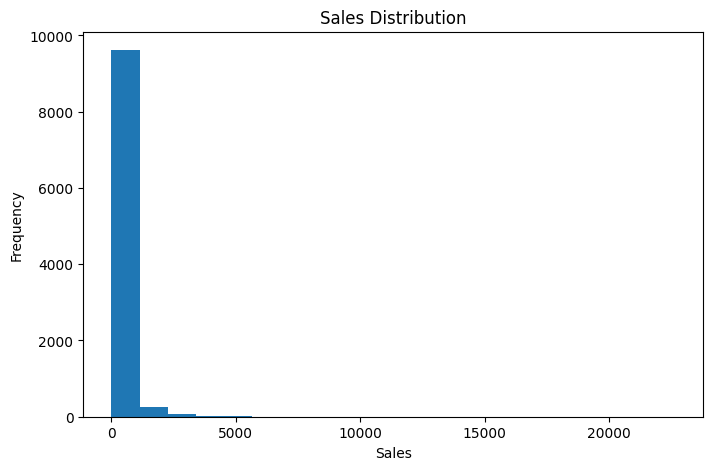

In [12]:
if 'sales' in df.columns:

    plt.figure(figsize=(8,5))

    plt.hist(df['sales'], bins=20)

    plt.title('Sales Distribution')

    plt.xlabel('Sales')

    plt.ylabel('Frequency')

    plt.show()

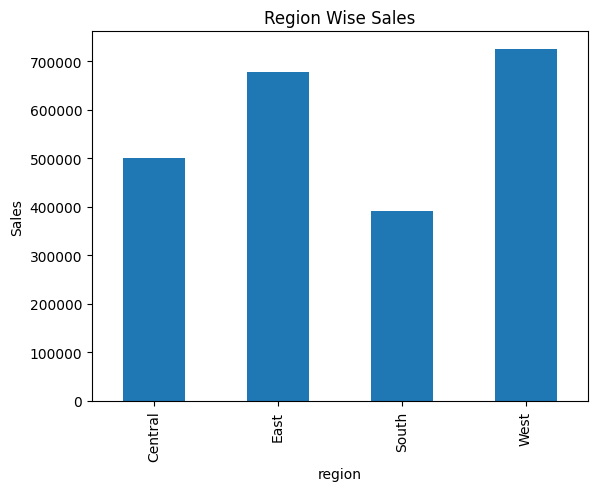

In [13]:
if 'region' in df.columns and 'sales' in df.columns:

    region_sales = df.groupby('region')['sales'].sum()

    region_sales.plot(kind='bar')

    plt.title('Region Wise Sales')

    plt.ylabel('Sales')

    plt.show()

In [14]:
df.to_csv('cleaned_sales_data.csv', index=False)

print("Cleaned CSV Saved")

Cleaned CSV Saved


In [15]:
with pd.ExcelWriter('summary_report.xlsx') as writer:

    df.to_excel(writer,
                sheet_name='Cleaned_Data',
                index=False)

    summary.to_excel(writer,
                     sheet_name='Summary')

print("Excel Report Generated")

Excel Report Generated


In [16]:
files.download('cleaned_sales_data.csv')

files.download('summary_report.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>